In [379]:
import numpy as np
import time
import sys
import math

import matplotlib.pyplot as plt

import qiskit
from qiskit import QuantumRegister as Q_R
from qiskit import ClassicalRegister as C_R
from qiskit_aer import Aer
from qiskit_aer import AerSimulator
from qiskit import QuantumCircuit, transpile

import bluequbit

import qiskit.qasm2

In [380]:
q = qiskit.qasm2.load("circuit_3_60q.qasm")

In [5]:
#Qubits rearragement
qubits_rearr_table = []
qubits_rearr_table.append([0,0])
qubits_rearr_table.append([1,1])
qubits_rearr_table.append([2,2])
qubits_rearr_table.append([3,3])
qubits_rearr_table.append([4,4])
qubits_rearr_table.append([5,5])
qubits_rearr_table.append([6,6])
qubits_rearr_table.append([7,36])
qubits_rearr_table.append([8,7])
qubits_rearr_table.append([9,8])
qubits_rearr_table.append([10,9])
qubits_rearr_table.append([11,10])
qubits_rearr_table.append([12,11])
qubits_rearr_table.append([13,12])
qubits_rearr_table.append([14,13])
qubits_rearr_table.append([15,14])
qubits_rearr_table.append([16,15])
qubits_rearr_table.append([17,16])
qubits_rearr_table.append([18,17])
qubits_rearr_table.append([19,18])
qubits_rearr_table.append([20,31])
qubits_rearr_table.append([21,43])
qubits_rearr_table.append([22,45])
qubits_rearr_table.append([23,19])
qubits_rearr_table.append([24,20])
qubits_rearr_table.append([25,21])
qubits_rearr_table.append([26,47])
qubits_rearr_table.append([27,39])
qubits_rearr_table.append([28,22])
qubits_rearr_table.append([29,50])
qubits_rearr_table.append([30,23])
qubits_rearr_table.append([31,24])
qubits_rearr_table.append([32,25])
qubits_rearr_table.append([33,51])
qubits_rearr_table.append([34,33])
qubits_rearr_table.append([35,26])
qubits_rearr_table.append([36,30])
qubits_rearr_table.append([37,56])
qubits_rearr_table.append([38,27])
qubits_rearr_table.append([39,48])
qubits_rearr_table.append([40,53])
qubits_rearr_table.append([41,42])
qubits_rearr_table.append([42,28])
qubits_rearr_table.append([43,58])
qubits_rearr_table.append([44,35])
qubits_rearr_table.append([45,54])
qubits_rearr_table.append([46,46])
qubits_rearr_table.append([47,34])
qubits_rearr_table.append([48,37])
qubits_rearr_table.append([49,29])
qubits_rearr_table.append([50,41])
qubits_rearr_table.append([51,57])
qubits_rearr_table.append([52,40])
qubits_rearr_table.append([53,52])
qubits_rearr_table.append([54,49])
qubits_rearr_table.append([55,55])
qubits_rearr_table.append([56,32])
qubits_rearr_table.append([57,59])
qubits_rearr_table.append([58,38])
qubits_rearr_table.append([59,44])

In [381]:
def reorganize_qubits(qc):
    qc_len = len(qc.data)
    qc_re = QuantumCircuit(30,30)
    for i in range(qc_len):
        cur_gate = qc.data[i]
        if cur_gate[0].name == 'rz':
            cur_angle_1 = cur_gate[0].params[0]
            curr_q = cur_gate[1][0]._index
            new_ind = qubits_rearr_table[curr_q][1]
            gate = qiskit.circuit.library.RZGate(cur_angle_1)
            if new_ind < 30:
                qc_re.append(gate, [new_ind])
        if cur_gate[0].name == 'sx':
            curr_q = cur_gate[1][0]._index
            new_ind = qubits_rearr_table[curr_q][1]
            gate = qiskit.circuit.library.SXGate()
            if new_ind < 30:
                qc_re.append(gate, [new_ind])
        if cur_gate[0].name == 'x':
            curr_q = cur_gate[1][0]._index
            new_ind = qubits_rearr_table[curr_q][1]
            gate = qiskit.circuit.library.XGate()
            if new_ind < 30:
                qc_re.append(gate, [new_ind])
        if cur_gate[0].name == 'cz':
            curr_q_1 = cur_gate[1][0]._index
            new_ind_1 = qubits_rearr_table[curr_q_1][1]
            curr_q_2 = cur_gate[1][1]._index
            new_ind_2 = qubits_rearr_table[curr_q_2][1]
            #print([curr_q_1,curr_q_2])
            gate = qiskit.circuit.library.CZGate()
            if new_ind_1 < 30 and new_ind_2 < 30:
                qc_re.append(gate, [new_ind_1, new_ind_2])  
    
    return qc_re

In [382]:
qc_reorg = reorganize_qubits(q)


In [8]:
#bq = bluequbit.init("ifvQUoJTa445RywgR6thzt5D2dCtAezL")
#result = bq.run(qc_reorg, device='cpu', shots = 1000)

In [9]:
#Getting the counts and hystogram (take long time!)
#from qiskit.visualization import plot_histogram
#counts = result.get_counts()
#plot_histogram(counts, title = 'results')

In [10]:
#counts

In [11]:
#Getting the most probable bit string
#for dic in counts:
#    if counts[dic] > 1:
#        ans = dic
#print(ans)
#print(counts[ans])

In [383]:
def get_closed_circuit(qc, q_list):
    qc_len = len(qc.data)
    q_list_len = len(q_list)
    qc_re = QuantumCircuit(q_list_len)
    for i in range(qc_len):
        cur_gate = qc.data[i]
        if cur_gate[0].name == 'rz':
            cur_angle_1 = cur_gate[0].params[0]
            curr_q = cur_gate[1][0]._index
            if curr_q in q_list:
                new_ind = q_list.index(curr_q)
                gate = qiskit.circuit.library.RZGate(cur_angle_1)
                qc_re.append(gate, [new_ind])
        if cur_gate[0].name == 'sx':
            curr_q = cur_gate[1][0]._index
            if curr_q in q_list:
                new_ind = q_list.index(curr_q)
                gate = qiskit.circuit.library.SXGate()
                qc_re.append(gate, [new_ind])
        if cur_gate[0].name == 'x':
            curr_q = cur_gate[1][0]._index
            if curr_q in q_list:
                new_ind = q_list.index(curr_q)
                gate = qiskit.circuit.library.XGate()
                qc_re.append(gate, [new_ind])
        if cur_gate[0].name == 'cz':
            curr_q_1 = cur_gate[1][0]._index
            curr_q_2 = cur_gate[1][1]._index
            if (curr_q_1 in q_list) and (curr_q_2 in q_list):
                new_ind_1 = q_list.index(curr_q_1)
                new_ind_2 = q_list.index(curr_q_2)
                gate = qiskit.circuit.library.CZGate()
                qc_re.append(gate, [new_ind_1, new_ind_2])
            if ((curr_q_1 not in q_list) and (curr_q_2 in q_list)) or ((curr_q_1 in q_list) and (curr_q_2 not in q_list)):
                print(curr_q_1)
                print(curr_q_2)
                break
            
    qc_re.measure_all()
    return qc_re

In [384]:
q_list = [37, 27, 25, 0]#, 50, 18, 46, 55, 7, 4, 40, 42, 56, 34, 48, 44, 41, 21, 51, 23, 49, 15, 19, 48, 29, 47, 1, 6, 29, 22, 32, 17, 26, 12, 36, 33]
q_list = [37, 27, 35, 10, 25, 0, 29, 48, 44, 46, 55, 47, 6, 50, 18]#, 50, 18, 46, 55, 7, 4, 40, 42, 56, 34, 48, 44, 41, 21, 51, 23, 49, 15, 19, 48, 29, 47, 1, 6, 29, 22, 32, 17, 26, 12, 36, 33]
len(q_list)

15

In [385]:
qq = get_closed_circuit(q, q_list)

55
7


In [386]:
len(qq)

363

In [16]:
#qq.draw('mpl')

In [17]:
#bq = bluequbit.init("ifvQUoJTa445RywgR6thzt5D2dCtAezL")
#result = bq.run(qq, device='cpu', shots = 1000)

In [20]:
#Getting the counts and hystogram (take long time!)
#from qiskit.visualization import plot_histogram
#counts = result.get_counts()
#plot_histogram(counts, title = 'results')

In [21]:
#counts

In [387]:
q_len = 15
av = np.zeros(q_len)
for key, value in counts.items():
    array_representation = [int(bit) for bit in key]
    #print(array_representation)
    #print(value)
    for i_q in range(q_len):
        av[i_q] = av[i_q] + array_representation[i_q] * value
for i_q in range(q_len):
    av[i_q] = av[i_q]/1000
    

IndexError: list index out of range

In [388]:
av

array([0., 0., 0., 0., 0., 0., 0., 0., 4., 0., 0., 0., 0., 0., 0.])

In [389]:
#the function finds the last gate using qubit qbit_num in circuit qc
def last_gate_m(qc, qbit_num, max_gate):
    qubit_last_gate = -1
    qc_len = len(qc.data)
    for i in range(max_gate - 1, -1, -1):
        cur_gate = qc.data[i]
        qubits_number = len(cur_gate[1])
        found = 0
        for i_q in range(qubits_number):
            if cur_gate[1][i_q]._index == qbit_num:
                qubit_last_gate = i
                found = 1
        if found == 1:
            break
    return qubit_last_gate

In [390]:
def light_cone(qc, qbit_num, max_gate):
    start_point = last_gate_m(qc, qbit_num, max_gate)
    qc_len = len(qc.data)
    cone_list = []
    cone_list.append(qbit_num)
    for i in range(start_point, -1, -1):
        cur_gate = qc.data[i]
        qubits_number = len(cur_gate[1])
        #Get qubits list for current gate
        q_list = []
        for i_q in range(qubits_number):
            q_list.append(cur_gate[1][i_q]._index)
        #check if qubits particiapating in the gate are in the list of the light cone or not
        if qubits_number > 1:
            if (q_list[0] in cone_list) and (q_list[1] not in cone_list):
                cone_list.append(q_list[1])
            if (q_list[1] in cone_list) and (q_list[0] not in cone_list):
                cone_list.append(q_list[0])
    return cone_list, len(cone_list), start_point

In [391]:
def get_closed_circuit_2(qc, q_list, max_gate):
    qc_len = len(qc.data)
    q_list_len = len(q_list)
    qc_re = QuantumCircuit(q_list_len)
    for i in range(max_gate + 1):
        cur_gate = qc.data[i]
        if cur_gate[0].name == 'rz':
            cur_angle_1 = cur_gate[0].params[0]
            curr_q = cur_gate[1][0]._index
            if curr_q in q_list:
                new_ind = q_list.index(curr_q)
                gate = qiskit.circuit.library.RZGate(cur_angle_1)
                qc_re.append(gate, [new_ind])
        if cur_gate[0].name == 'sx':
            curr_q = cur_gate[1][0]._index
            if curr_q in q_list:
                new_ind = q_list.index(curr_q)
                gate = qiskit.circuit.library.SXGate()
                qc_re.append(gate, [new_ind])
        if cur_gate[0].name == 'x':
            curr_q = cur_gate[1][0]._index
            if curr_q in q_list:
                new_ind = q_list.index(curr_q)
                gate = qiskit.circuit.library.XGate()
                qc_re.append(gate, [new_ind])
        if cur_gate[0].name == 'cz':
            curr_q_1 = cur_gate[1][0]._index
            curr_q_2 = cur_gate[1][1]._index
            if (curr_q_1 in q_list) and (curr_q_2 in q_list):
                new_ind_1 = q_list.index(curr_q_1)
                new_ind_2 = q_list.index(curr_q_2)
                gate = qiskit.circuit.library.CZGate()
                qc_re.append(gate, [new_ind_1, new_ind_2])
    qc_re.measure_all()
    return qc_re

In [413]:
q_list, q_list_len, max_gate = light_cone(q, 29, 570)
print(q_list)
print(len(q_list))
print(max_gate)

[29, 25, 48, 46, 47, 6, 44, 55, 0]
9
486


In [414]:
qq = get_closed_circuit_2(q, q_list, max_gate)
print(len(qq))


249


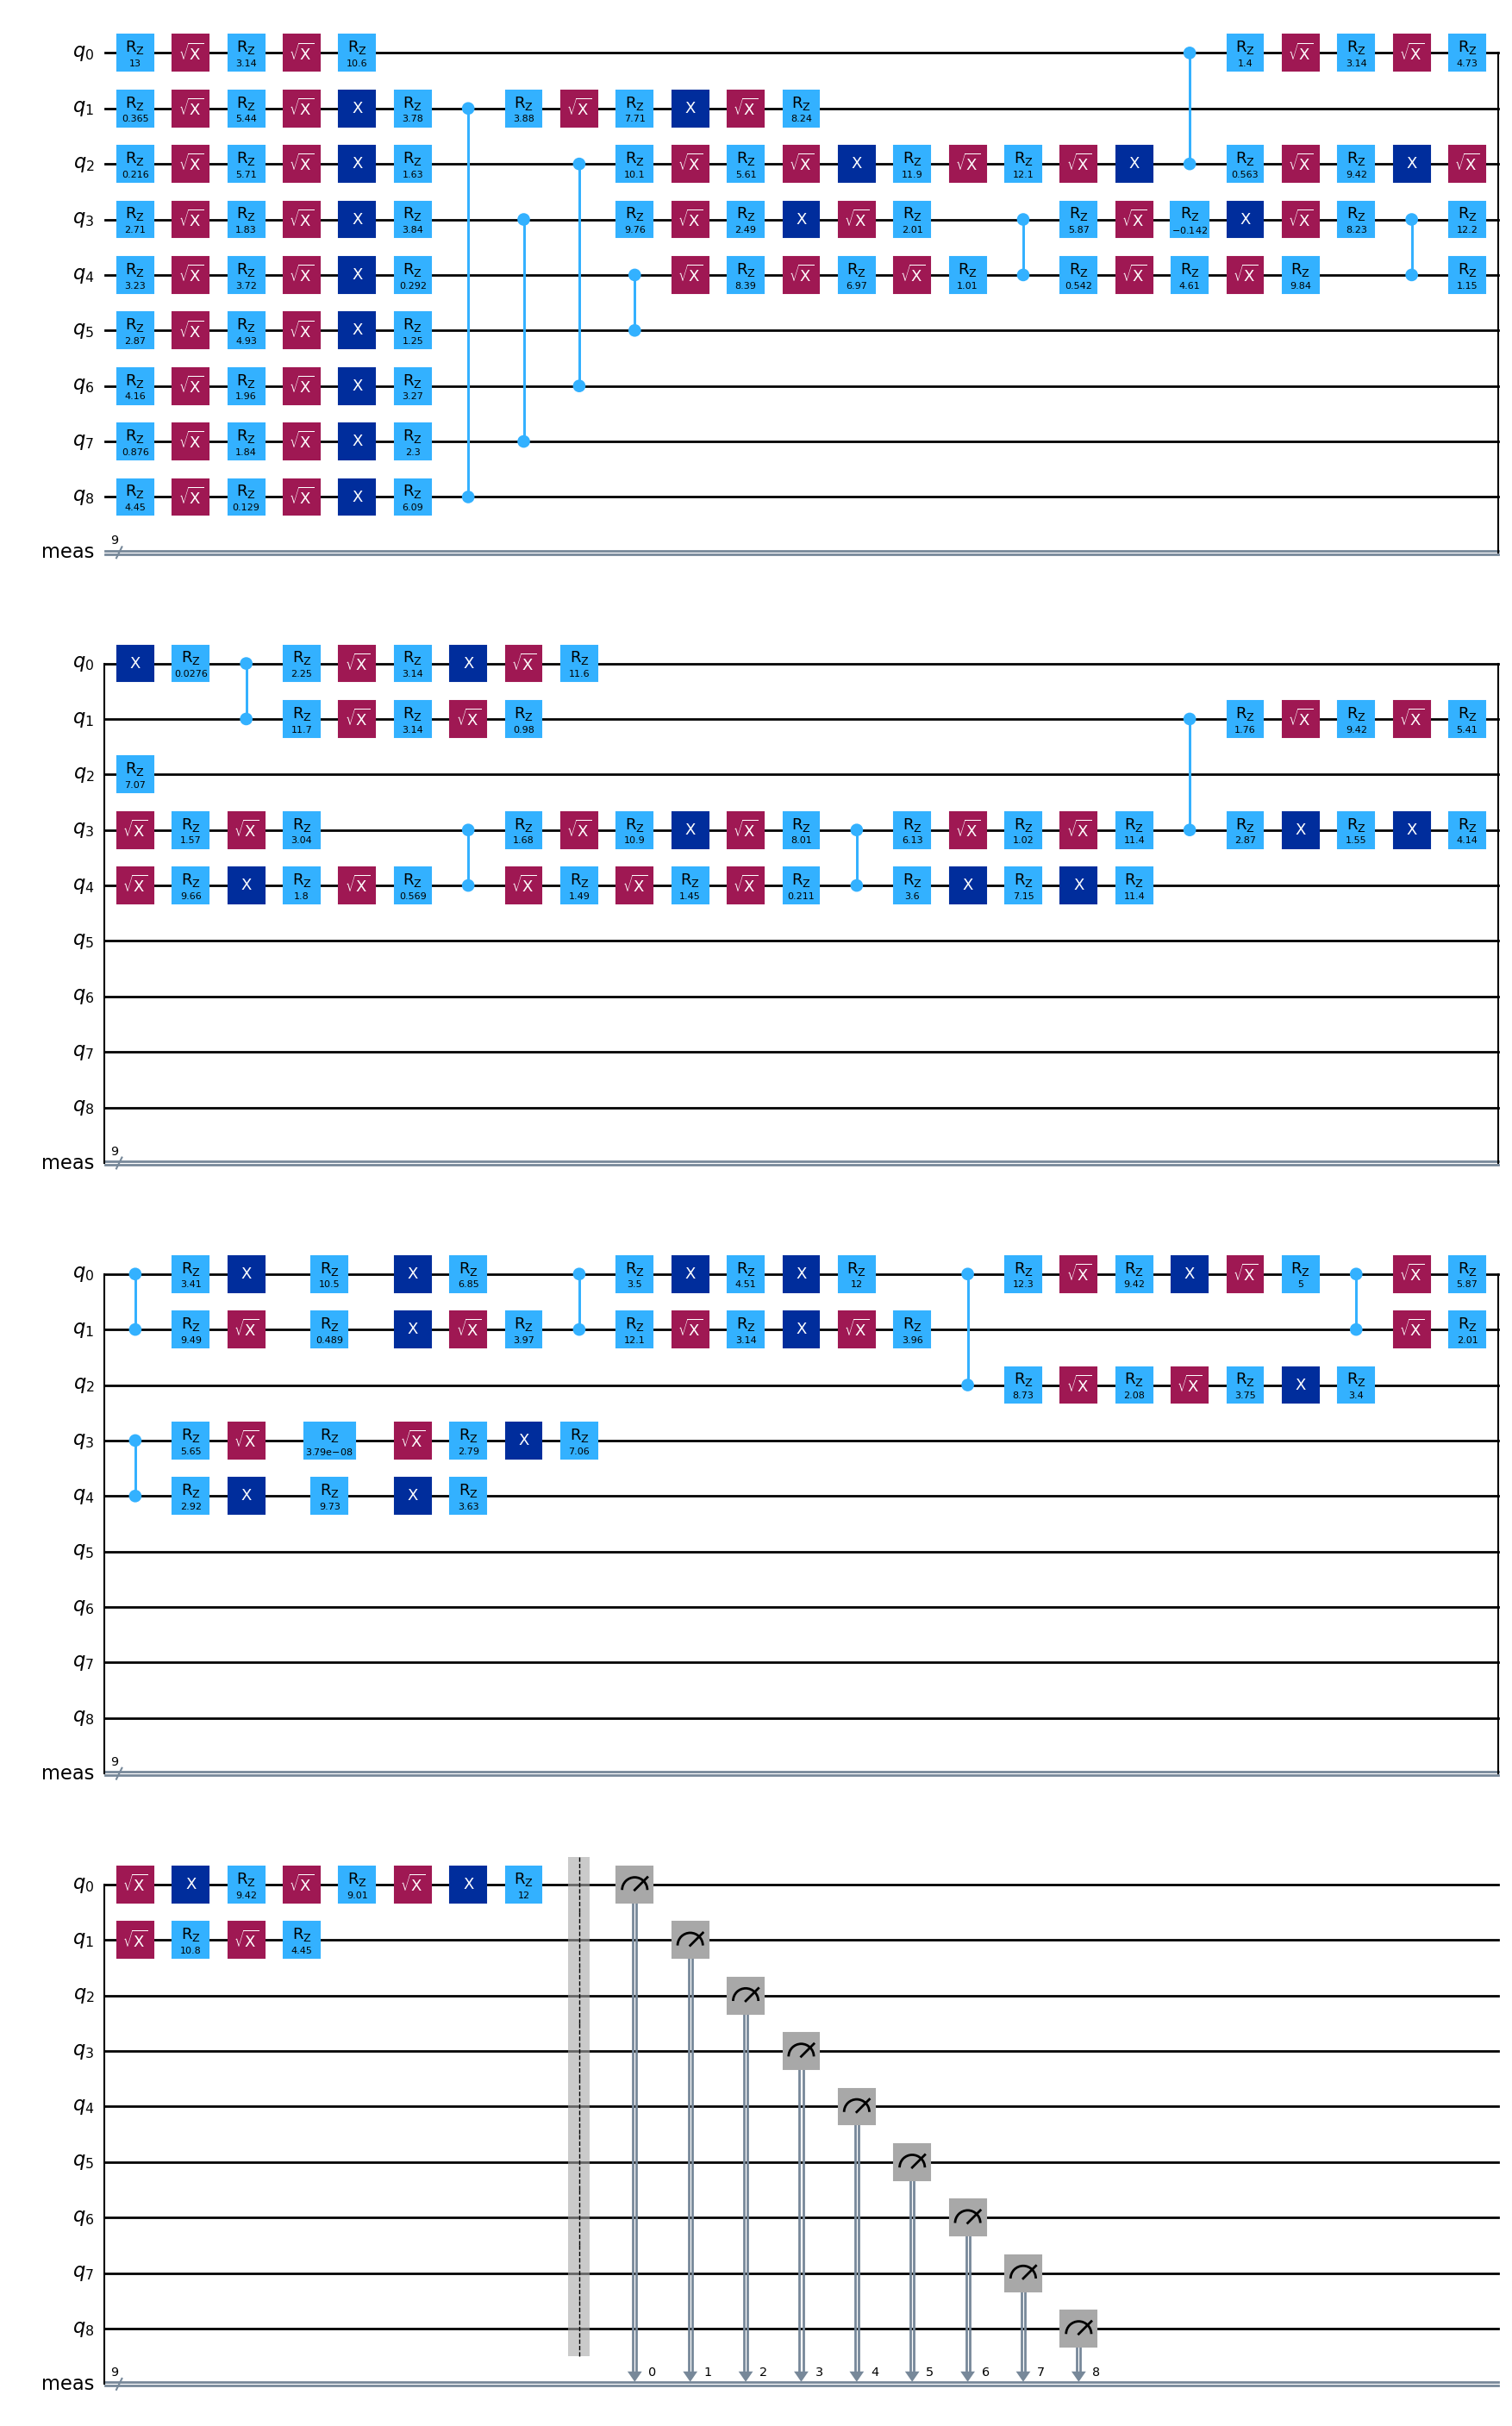

In [415]:
qq.draw('mpl')

In [34]:
bq = bluequbit.init("ifvQUoJTa445RywgR6thzt5D2dCtAezL")
result = bq.run(qq, device='cpu', shots = 1000)

BQ-PYTHON-SDK - WARNING - Beta version 0.8.3b1 of BlueQubit Python SDK is being used.
BQ-PYTHON-SDK - INFO - There is a newer version of BlueQubit Python SDK available on PyPI. We recommend upgrading. Run 'pip install --upgrade bluequbit' to upgrade from your version 0.8.3b1 to 0.11.0b1.
BQ-PYTHON-SDK - INFO - Submitted: Job ID: YzB6IlsHFU3KtRaR, device: cpu, run status: COMPLETED, created on: 2025-04-10 00:02:56 UTC, cost: $0.00, run time: 25 ms, queue time: 109 ms, num qubits: 9


In [35]:
#Getting the counts and hystogram (take long time!)
from qiskit.visualization import plot_histogram
counts = result.get_counts()


q_len = len(q_list)
av = np.zeros(q_len)
for key, value in counts.items():
    array_representation = [int(bit) for bit in key]
    #print(array_representation)
    #print(value)
    for i_q in range(q_len):
        av[i_q] = av[i_q] + array_representation[i_q] * value
for i_q in range(q_len):
    av[i_q] = av[i_q]/1000

av

array([0.001, 0.643, 0.675, 0.384, 0.061, 0.   , 0.929, 0.63 , 0.642])

BQ-PYTHON-SDK - WARNING - Beta version 0.8.3b1 of BlueQubit Python SDK is being used.
BQ-PYTHON-SDK - INFO - There is a newer version of BlueQubit Python SDK available on PyPI. We recommend upgrading. Run 'pip install --upgrade bluequbit' to upgrade from your version 0.8.3b1 to 0.12.0b1.


['TEST QUBIT: ', '29', '\n\n']


BQ-PYTHON-SDK - INFO - Submitted: Job ID: 9900JO6fDoa8JrQT, device: cpu, run status: COMPLETED, created on: 2025-04-10 18:53:31 UTC, cost: $0.00, run time: 22 ms, queue time: 127 ms, num qubits: 9


['qubits list: ', '[29, 25, 48, 46, 47, 6, 44, 55, 0]']
['qubits number: ', '9']
['last gate: ', '486']
['reduced circuit length: ', '249']
[0.005 0.621 0.686 0.407 0.767 0.371 0.08  0.363 0.   ]


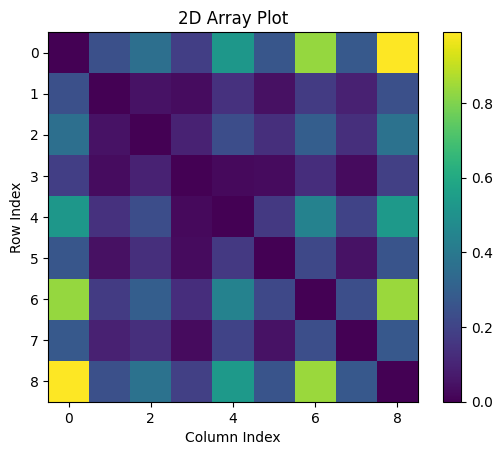

In [417]:
for j_q in range(29,30):
    print(['TEST QUBIT: ', str(j_q), '\n\n'])
    q_num = j_q
    previous_length = 0
    for n_gates in range(100,1000,500):
        q_list, q_list_len, max_gate = light_cone(q, q_num, n_gates)
        qq = []
        qq = get_closed_circuit_2(q, q_list, max_gate)
        if  (max_gate > previous_length) and (q_list_len < 30):
            previous_length = max_gate
            bq = bluequbit.init("ifvQUoJTa445RywgR6thzt5D2dCtAezL")
            result = bq.run(qq, device='cpu', shots = 1000)
            counts = result.get_counts()
            q_len = len(q_list)
            av = np.zeros(q_len)
            corr = np.zeros((q_len, q_len))
            for key, value in counts.items():
                array_representation = [int(bit) for bit in key]
                for i_q in range(q_len):
                    av[i_q] = av[i_q] + array_representation[i_q] * value
            for i_q in range(q_len):
                av[i_q] = av[i_q]/1000
            for key, value in counts.items():
                array_representation = [int(bit) for bit in key]
                for i_q in range(q_len):
                    for j_q in range(q_len):
                        if i_q != j_q:
                            corr[i_q][j_q] = corr[i_q][j_q] + (array_representation[j_q] -  0.5)* (array_representation[i_q] -  0.5) * value
            for i_q in range(q_len):
                corr[i_q] = abs(corr[i_q]/1000/0.25)
            print(['qubits list: ', str(q_list)])
            print(['qubits number: ', str(len(q_list))])
            print(['last gate: ', str(max_gate)])
            print(['reduced circuit length: ', str(len(qq))])
            print(av)
            #print(corr)
            plt.imshow(corr, cmap='viridis')  # Use a colormap for visualization
            plt.colorbar()  # Add a colorbar to show value mapping
            plt.title('2D Array Plot')
            plt.xlabel('Column Index')
            plt.ylabel('Row Index')
            plt.show()

In [426]:
#the function finds the last gate using qubit qbit_num in circuit qc
def first_gate(qc, qbit_num):
    qubit_first_gate = -1
    qc_len = len(qc.data)
    for i in range(qc_len):
        cur_gate = qc.data[i]
        qubits_number = len(cur_gate[1])
        found = 0
        for i_q in range(qubits_number):
            if cur_gate[1][i_q]._index == qbit_num:
                qubit_first_gate = i
                found = 1
        if found == 1:
            break
    return qubit_first_gate

In [427]:
def forward_light_cone(qc, qbit_num):
    start_point = first_gate(qc, qbit_num)
    qc_len = len(qc.data)
    cone_list = []
    cone_list.append(qbit_num)
    for i in range(start_point-1, qc_len):
        cur_gate = qc.data[i]
        qubits_number = len(cur_gate[1])
        #Get qubits list for current gate
        q_list = []
        for i_q in range(qubits_number):
            q_list.append(cur_gate[1][i_q]._index)
        #check if qubits particiapating in the gate are in the list of the light cone or not
        if qubits_number > 1:
            if (q_list[0] in cone_list) and (q_list[1] not in cone_list):
                cone_list.append(q_list[1])
            if (q_list[1] in cone_list) and (q_list[0] not in cone_list):
                cone_list.append(q_list[0])
    return cone_list, len(cone_list), start_point

In [432]:
for i_q in range(60):
    cone_list, list_len, start_point = forward_light_cone(q, i_q)
    print(list_len)
    print(start_point)
    print('')

60
19

60
513

60
225

60
231

60
58

60
244

60
199

60
52

60
238

60
539

60
153

60
693

60
173

60
251

60
257

60
136

60
526

60
186

60
32

60
143

60
660

60
110

60
673

60
123

60
520

60
13

60
179

60
6

60
552

60
322

60
212

60
680

60
192

60
160

60
84

60
147

60
166

60
0

60
264

60
290

60
65

60
104

60
71

60
218

60
97

60
533

60
39

60
205

60
91

60
130

60
26

60
117

60
546

60
316

60
270

60
45

60
78

60
277

60
686

60
283



In [429]:
first_gate(q, 29)

322

In [431]:
list_len

60

In [ ]:
#the function finds the last gate using qubit qbit_num in circuit qc
def last_gate_m(qc, qbit_num, max_gate):
    qubit_last_gate = -1
    qc_len = len(qc.data)
    for i in range(max_gate - 1, -1, -1):
        cur_gate = qc.data[i]
        qubits_number = len(cur_gate[1])
        found = 0
        for i_q in range(qubits_number):
            if cur_gate[1][i_q]._index == qbit_num:
                qubit_last_gate = i
                found = 1
        if found == 1:
            break
    return qubit_last_gate

In [447]:
def light_cone(qc, qbit_num, max_gate):
    qc_len = len(qc.data)
    start_point = last_gate_m(qc, qbit_num, qc_len-1)
    cone_list = []
    cone_list.append(qbit_num)
    coupling_list = []
    for i in range(start_point, -1, -1):
        cur_gate = qc.data[i]
        qubits_number = len(cur_gate[1])
        #Get qubits list for current gate
        q_list = []
        for i_q in range(qubits_number):
            q_list.append(cur_gate[1][i_q]._index)
        #check if qubits particiapating in the gate are in the list of the light cone or not
        if qubits_number > 1:
            if (q_list[0] in cone_list) and (q_list[1] not in cone_list):
                cone_list.append(q_list[1])
                coupling_list.append([q_list[0], q_list[1]])
            if (q_list[1] in cone_list) and (q_list[0] not in cone_list):
                cone_list.append(q_list[0])
                coupling_list.append([q_list[0], q_list[1]])
            if (q_list[1] in cone_list) and (q_list[0] in cone_list):
                coupling_list.append([q_list[0], q_list[1]])
            
    return cone_list, len(cone_list), start_point, coupling_list

In [448]:
cone_list, q_len, start_point, coupling_list = light_cone(q, 29, 0)

In [450]:
coupling_list

[[20, 29],
 [20, 29],
 [7, 29],
 [7, 29],
 [18, 29],
 [18, 29],
 [18, 3],
 [18, 3],
 [45, 7],
 [45, 7],
 [18, 6],
 [18, 6],
 [18, 29],
 [18, 3],
 [18, 6],
 [18, 29],
 [7, 29],
 [45, 7],
 [18, 29],
 [45, 6],
 [29, 22],
 [29, 22],
 [39, 20],
 [39, 20],
 [18, 46],
 [18, 46],
 [45, 9],
 [45, 9],
 [2, 3],
 [2, 3],
 [6, 47],
 [6, 47],
 [22, 31],
 [22, 31],
 [20, 29],
 [7, 4],
 [7, 4],
 [46, 55],
 [46, 55],
 [50, 18],
 [50, 18],
 [9, 52],
 [9, 52],
 [16, 45],
 [16, 45],
 [1, 9],
 [1, 9],
 [0, 9],
 [0, 9],
 [1, 0],
 [1, 8],
 [1, 8],
 [9, 33],
 [9, 33],
 [9, 33],
 [1, 8],
 [1, 9],
 [1, 9],
 [1, 9],
 [1, 0],
 [0, 9],
 [59, 39],
 [59, 39],
 [3, 8],
 [43, 2],
 [43, 2],
 [47, 30],
 [47, 30],
 [32, 6],
 [32, 6],
 [10, 33],
 [10, 33],
 [4, 40],
 [4, 40],
 [55, 7],
 [18, 46],
 [0, 50],
 [41, 33],
 [41, 33],
 [55, 33],
 [55, 33],
 [0, 33],
 [41, 36],
 [41, 36],
 [55, 0],
 [41, 36],
 [41, 10],
 [55, 0],
 [0, 33],
 [41, 10],
 [55, 41],
 [55, 41],
 [41, 33],
 [31, 58],
 [31, 58],
 [29, 22],
 [39, 20],
 [5

In [ ]:
for j_q in range(29,30):
    print(['TEST QUBIT: ', str(j_q), '\n\n'])
    q_num = j_q
    previous_length = 0
    for n_gates in range(100,1000,500):
        q_list, q_list_len, max_gate = light_cone(q, q_num, n_gates)
        qq = []
        qq = get_closed_circuit_2(q, q_list, max_gate)
        if  (max_gate > previous_length) and (q_list_len < 30):
            previous_length = max_gate
            bq = bluequbit.init("ifvQUoJTa445RywgR6thzt5D2dCtAezL")
            result = bq.run(qq, device='cpu', shots = 1000)
            counts = result.get_counts()
            q_len = len(q_list)
            av = np.zeros(q_len)
            corr = np.zeros((q_len, q_len))
            for key, value in counts.items():
                array_representation = [int(bit) for bit in key]
                for i_q in range(q_len):
                    av[i_q] = av[i_q] + array_representation[i_q] * value
            for i_q in range(q_len):
                av[i_q] = av[i_q]/1000
            for key, value in counts.items():
                array_representation = [int(bit) for bit in key]
                for i_q in range(q_len):
                    for j_q in range(q_len):
                        if i_q != j_q:
                            corr[i_q][j_q] = corr[i_q][j_q] + (array_representation[j_q] -  0.5)* (array_representation[i_q] -  0.5) * value
            for i_q in range(q_len):
                corr[i_q] = abs(corr[i_q]/1000/0.25)
            print(['qubits list: ', str(q_list)])
            print(['qubits number: ', str(len(q_list))])
            print(['last gate: ', str(max_gate)])
            print(['reduced circuit length: ', str(len(qq))])
            print(av)
            #print(corr)
            plt.imshow(corr, cmap='viridis')  # Use a colormap for visualization
            plt.colorbar()  # Add a colorbar to show value mapping
            plt.title('2D Array Plot')
            plt.xlabel('Column Index')
            plt.ylabel('Row Index')
            plt.show()

In [560]:
def get_closed_circuit_3(qc, q_list):
    q_list_rem = []
    q_list_rem[:] = q_list[:]
    qc_len = len(qc.data)
    q_list_len = len(q_list)
    qc_re = QuantumCircuit(q_list_len)
    for i in range(qc_len):
        cur_gate = qc.data[i]
        if cur_gate[0].name == 'rz':
            cur_angle_1 = cur_gate[0].params[0]
            curr_q = cur_gate[1][0]._index
            if curr_q in q_list_rem:
                new_ind = q_list.index(curr_q)
                gate = qiskit.circuit.library.RZGate(cur_angle_1)
                qc_re.append(gate, [new_ind])
        if cur_gate[0].name == 'sx':
            curr_q = cur_gate[1][0]._index
            if curr_q in q_list_rem:
                new_ind = q_list.index(curr_q)
                gate = qiskit.circuit.library.SXGate()
                qc_re.append(gate, [new_ind])
        if cur_gate[0].name == 'x':
            curr_q = cur_gate[1][0]._index
            if curr_q in q_list_rem:
                new_ind = q_list.index(curr_q)
                gate = qiskit.circuit.library.XGate()
                qc_re.append(gate, [new_ind])
        if cur_gate[0].name == 'cz':
            curr_q_1 = cur_gate[1][0]._index
            curr_q_2 = cur_gate[1][1]._index
            if (curr_q_1 in q_list_rem) and (curr_q_2 in q_list_rem):
                new_ind_1 = q_list.index(curr_q_1)
                new_ind_2 = q_list.index(curr_q_2)
                gate = qiskit.circuit.library.CZGate()
                qc_re.append(gate, [new_ind_1, new_ind_2])
            if (curr_q_1 in q_list_rem) and (curr_q_2 not in q_list_rem):
                q_list_rem.remove(curr_q_1)
                print(str([curr_q_1, curr_q_2]))
            if (curr_q_1 not in q_list_rem) and (curr_q_2 in q_list_rem):
                q_list_rem.remove(curr_q_2)
                print(str([curr_q_1, curr_q_2]))
    qc_re.measure_all()
    return qc_re

In [701]:
q_list = [6, 47, 46, 32, 55, 17, 25, 0]
q_len = len(q_list)
q_1 = get_closed_circuit_3(q, q_list)

[25, 29]
[25, 46]
[46, 47]
[0, 50]
[55, 7]
[26, 17]
[17, 32]
[6, 47]


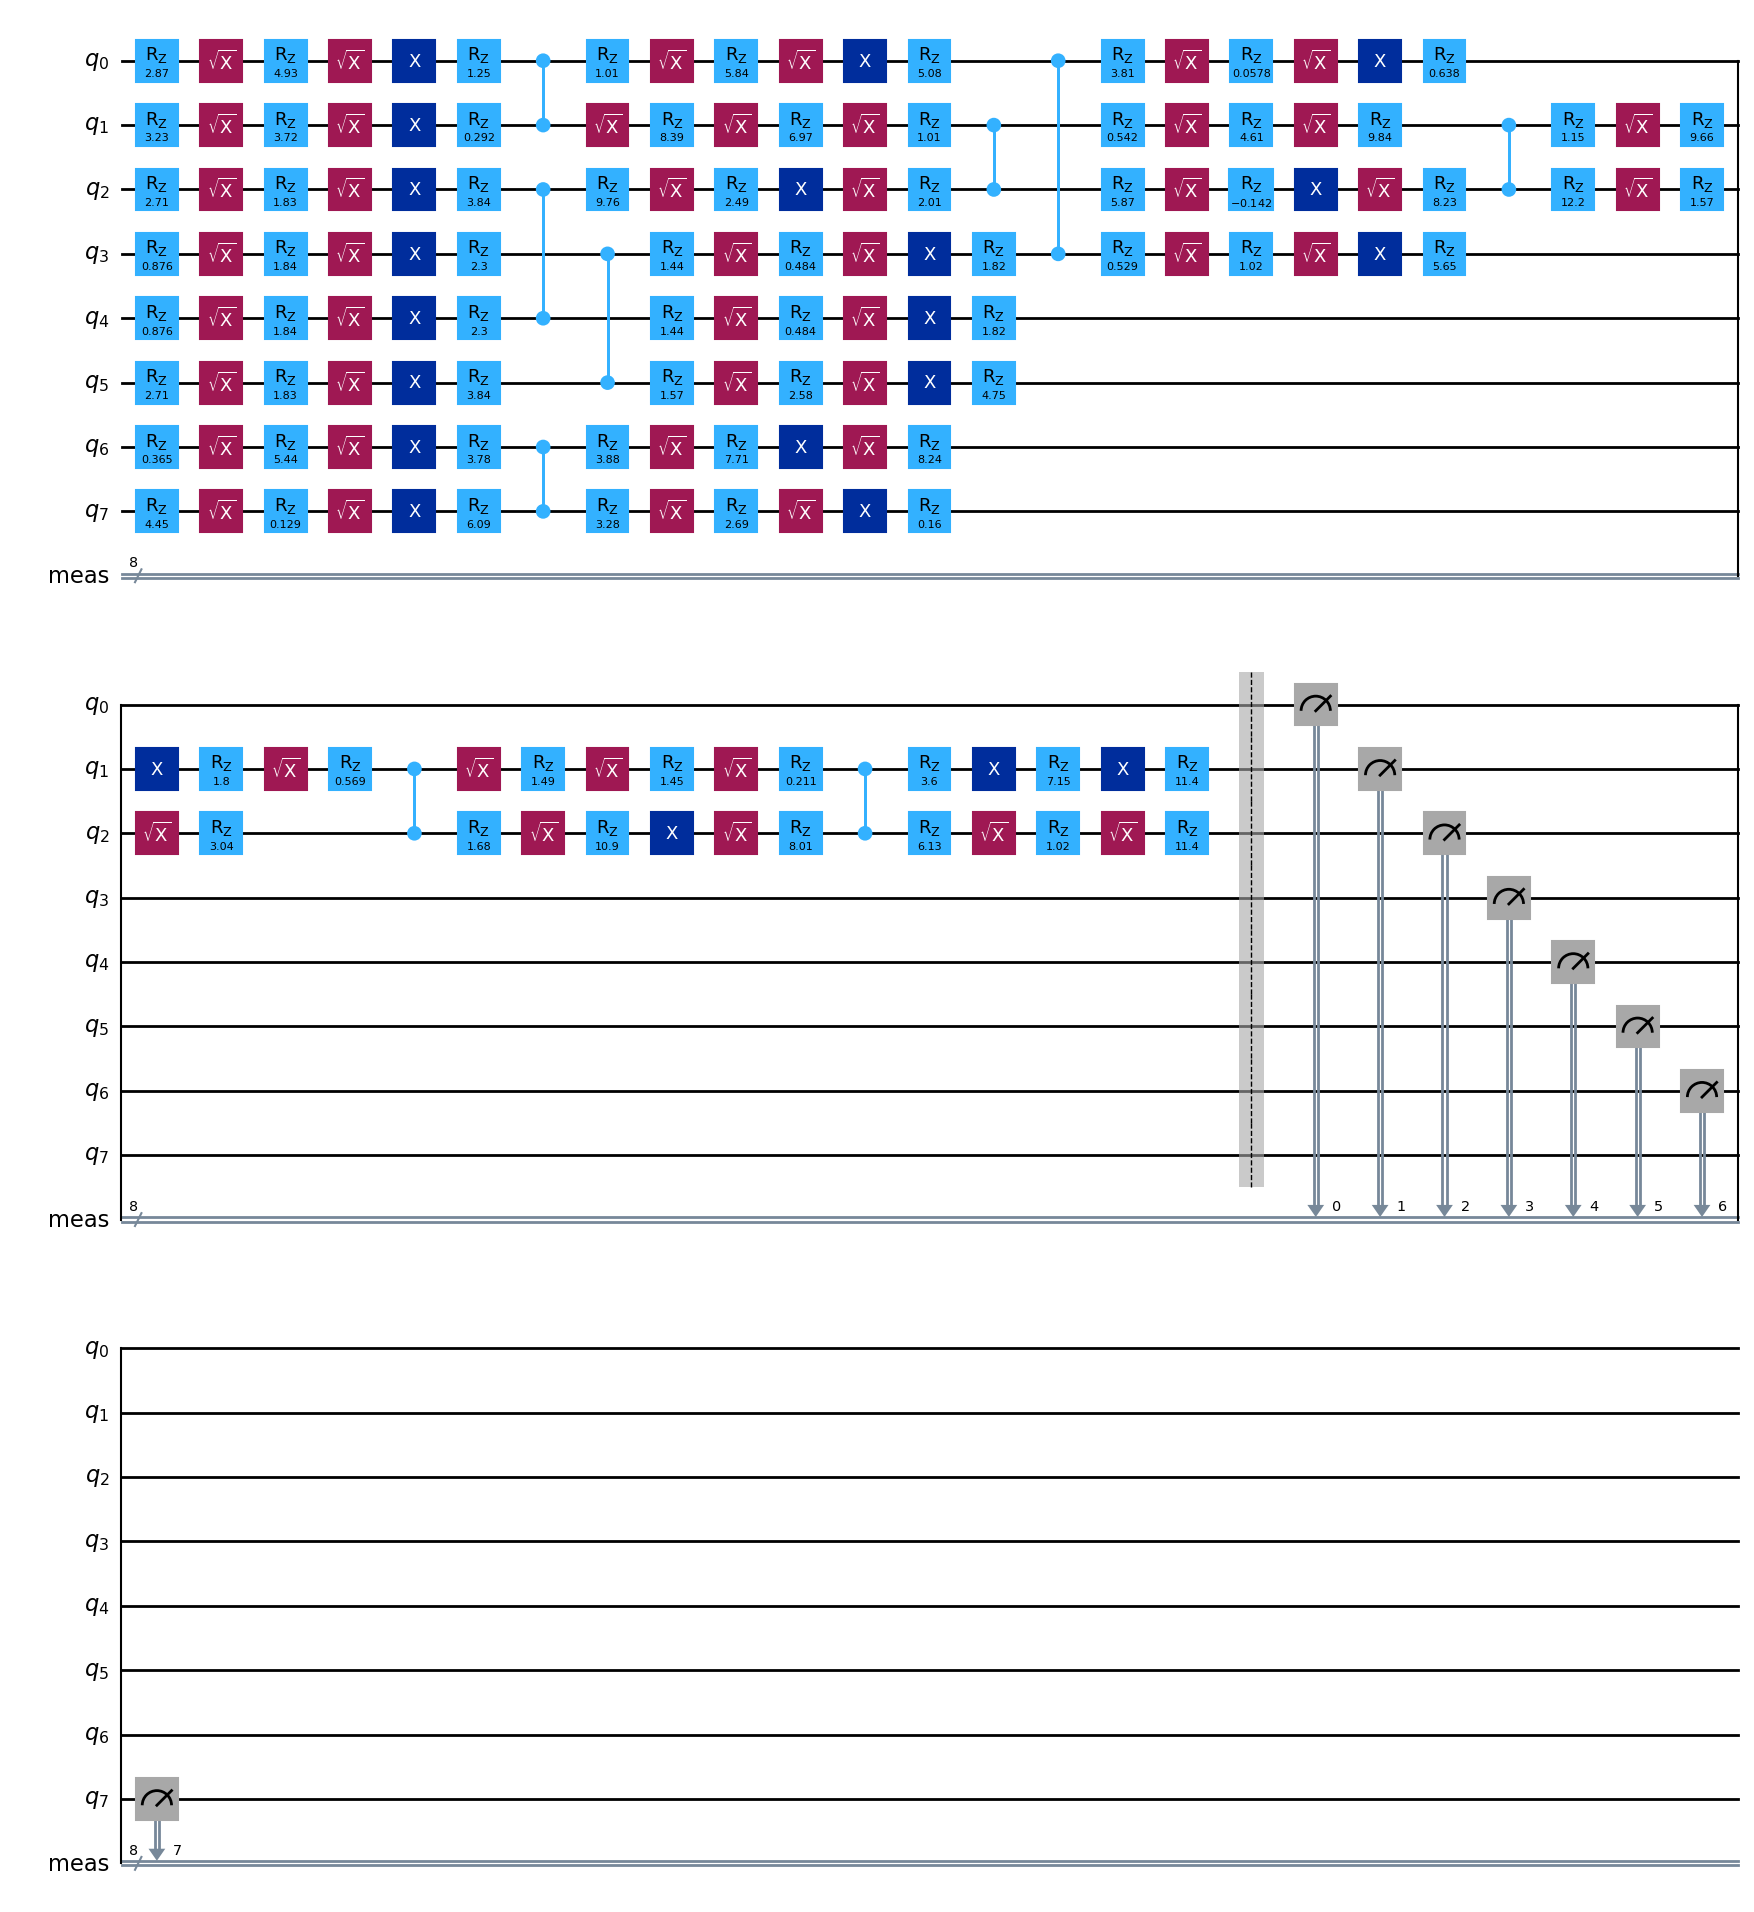

In [702]:
q_1.draw('mpl')

BQ-PYTHON-SDK - WARNING - Beta version 0.8.3b1 of BlueQubit Python SDK is being used.
BQ-PYTHON-SDK - INFO - There is a newer version of BlueQubit Python SDK available on PyPI. We recommend upgrading. Run 'pip install --upgrade bluequbit' to upgrade from your version 0.8.3b1 to 0.12.0b1.
BQ-PYTHON-SDK - INFO - Submitted: Job ID: j5vB1Wf4inY7BuFb, device: cpu, run status: COMPLETED, created on: 2025-04-11 20:13:56 UTC, cost: $0.00, run time: 17 ms, queue time: 106 ms, num qubits: 8


['qubits list: ', '[6, 47, 46, 32, 55, 17, 25, 0]']
['qubits number: ', '8']
['last gate: ', '486']
['reduced circuit length: ', '249']
[0.934 0.393 0.344 0.66  0.582 0.346 0.764 0.503]


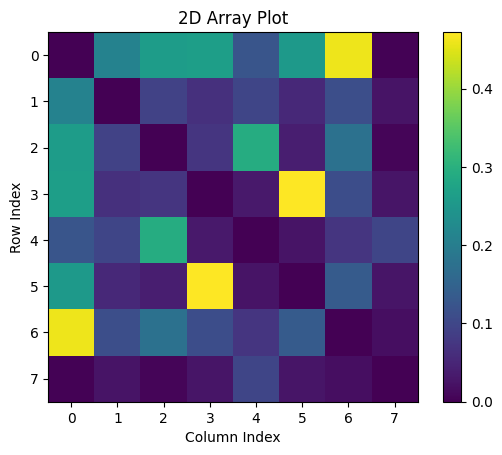

In [703]:
bq = bluequbit.init("ifvQUoJTa445RywgR6thzt5D2dCtAezL")
result = bq.run(q_1, device='cpu', shots = 1000)
counts = result.get_counts()
av = np.zeros(q_len)
corr = np.zeros((q_len, q_len))
for key, value in counts.items():
    array_representation = [int(bit) for bit in key]
    for i_q in range(q_len):
        av[i_q] = av[i_q] + array_representation[i_q] * value
for i_q in range(q_len):
    av[i_q] = av[i_q]/1000
for key, value in counts.items():
    array_representation = [int(bit) for bit in key]
    for i_q in range(q_len):
        for j_q in range(q_len):
            if i_q != j_q:
                corr[i_q][j_q] = corr[i_q][j_q] + (array_representation[j_q] -  0.5)* (array_representation[i_q] -  0.5) * value
for i_q in range(q_len):
    corr[i_q] = abs(corr[i_q]/1000/0.25)
print(['qubits list: ', str(q_list)])
print(['qubits number: ', str(len(q_list))])
print(['last gate: ', str(max_gate)])
print(['reduced circuit length: ', str(len(qq))])
print(av)
#print(corr)
plt.imshow(corr, cmap='viridis')  # Use a colormap for visualization
plt.colorbar()  # Add a colorbar to show value mapping
plt.title('2D Array Plot')
plt.xlabel('Column Index')
plt.ylabel('Row Index')
plt.show()

In [569]:
len(q_1.data)

55

In [566]:
#!pip install --upgrade bluequbit